# Test-Time Compute Scaling — Results & Plots

This notebook loads benchmark results from `logs/benchmark/` and generates the figures used in the README:

1. **`Figs/accuracy_vs_rollouts.png`** — Accuracy vs. rollout budget for all inference methods (1.5B and 7B generators).
2. **`Figs/prm_data_source_comparison.png`** — Effect of PRM training data source (1.5B-generated vs. 7B-generated data) at N=8.
3. **`Figs/accuracy_by_difficulty.png`** — Per-difficulty breakdown (requires per-difficulty fields in the results JSON).

**Note on beam search:** `beam_search` requires N ≥ beam_M (default M=4). Results with N < M are stored as 0.0 and are excluded from plots.

In [19]:
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from pathlib import Path

# ── Matplotlib style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

# ── Paths ─────────────────────────────────────────────────────────────────────
LOG_DIR  = Path('logs/benchmark')
FIGS_DIR = Path('Figs')
FIGS_DIR.mkdir(exist_ok=True)

print('Paths OK')

Paths OK


In [20]:
# ── Load all benchmark result files ───────────────────────────────────────────

def load_results(model_dir: str) -> list[dict]:
    """Load all results_rollouts* files."""
    pattern = str(LOG_DIR / model_dir / 'results_rollouts*')
    results = []
    for fpath in glob.glob(pattern):
        with open(fpath) as f:
            results.append(json.load(f))
    return sorted(results, key=lambda r: r['rollouts'])


def extract_series(results: list[dict], key: str, beam_M: int = 4):
    """Return (rollouts, accuracies_pct) for a given metric key.
    Beam-search entries where N < M are excluded (stored as 0.0 by the benchmark script).
    """
    xs, ys = [], []
    for r in results:
        N   = r['rollouts']
        acc = r['accuracies'][key]
        if 'beam_search' in key and N < beam_M:
            continue          # beam search not valid for N < M
        xs.append(N)
        ys.append(acc * 100)  # → percentage
    return xs, ys


results_1p5B = load_results('1.5B')
results_7B   = load_results('7B')

# Quick sanity-check
print('1.5B rollout budgets:', [r['rollouts'] for r in results_1p5B])
print(' 7B rollout budgets:', [r['rollouts'] for r in results_7B])

1.5B rollout budgets: [1, 2, 4, 8, 16]
 7B rollout budgets: [1, 2, 4, 8, 16]


## Figure 1 — Accuracy vs. Rollout Budget

Two side-by-side subplots: **left** = 1.5B generator, **right** = 7B generator.  
Colour encodes inference method type; line style encodes PRM training data source (solid = 1.5B data, dashed = 7B data).

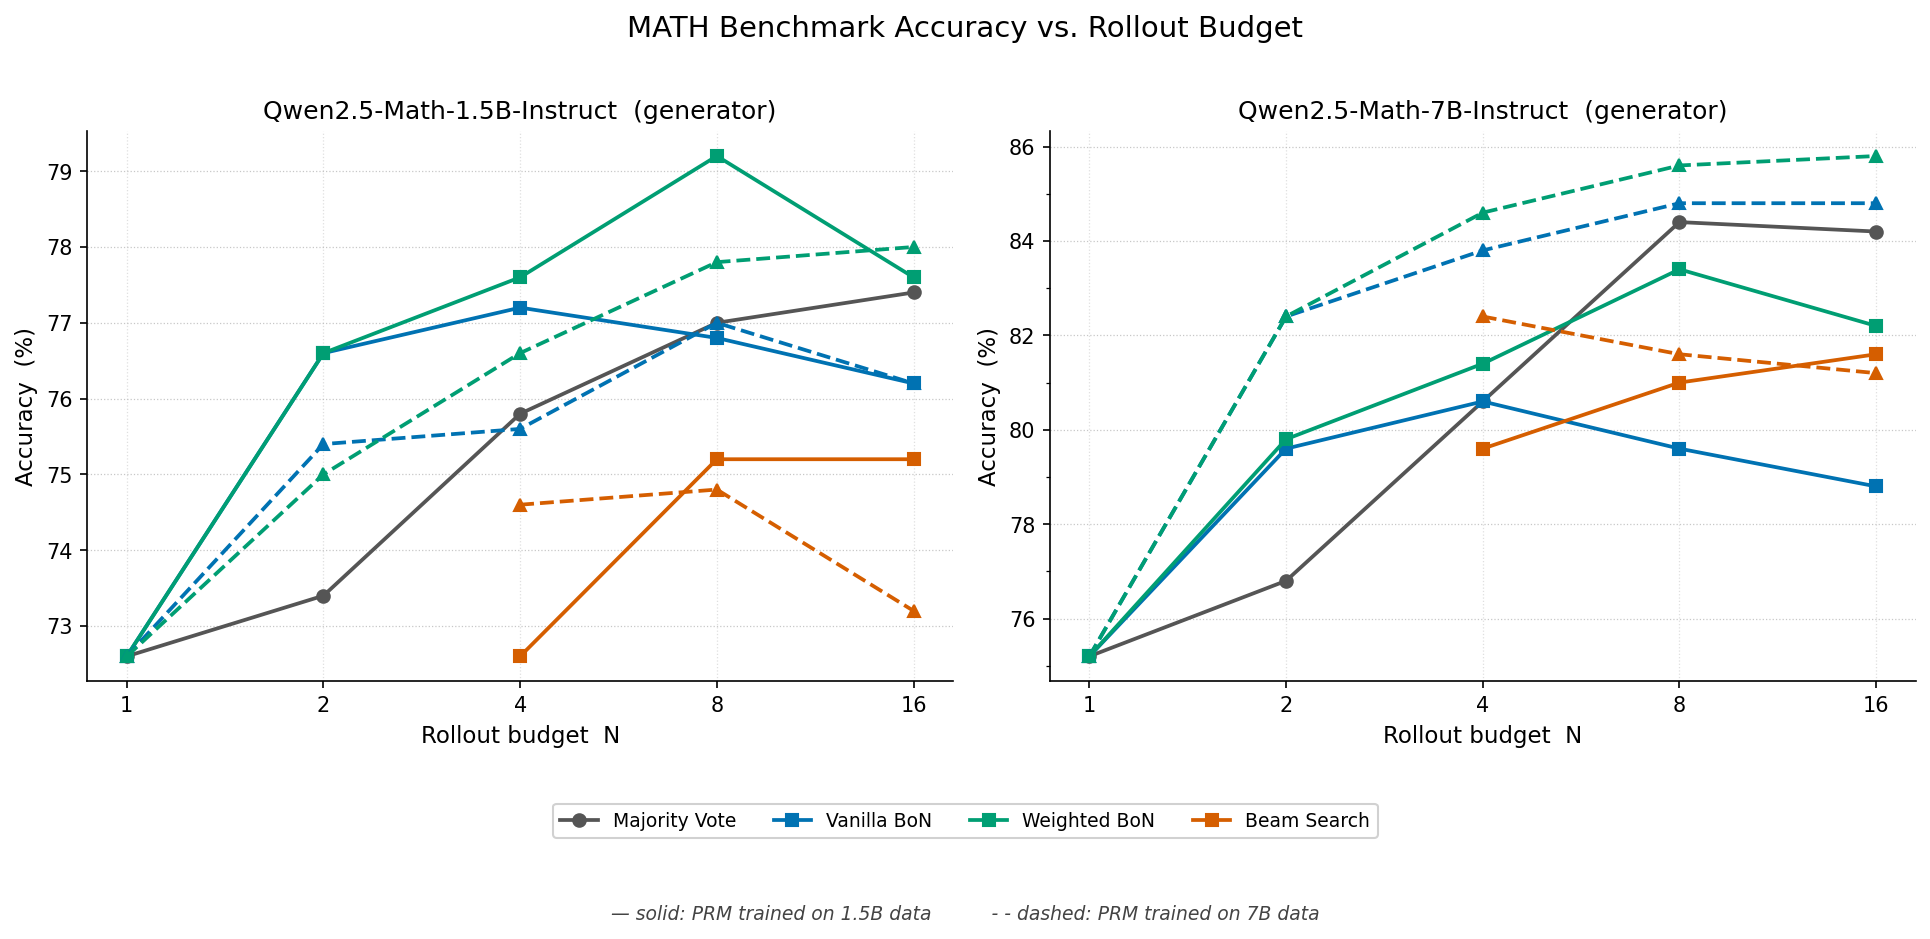

Saved → Figs/accuracy_vs_rollouts.png


In [21]:
# ── Colour / style palette ────────────────────────────────────────────────────
COLORS = {
    'majority':  '#555555',   # gray
    'vanilla':   '#0072B2',   # blue
    'weighted':  '#009E73',   # green
    'beam':      '#D55E00',   # orange-red
}

# (key, label, color, linestyle)
METHODS = [
    ('majority_vote',          'Majority Vote',              COLORS['majority'],  '-',  'o'),
    ('vanilla_best_of_N_15',   'Vanilla BoN (PRM 1.5B)',     COLORS['vanilla'],   '-',  's'),
    ('weighted_best_of_N_15',  'Weighted BoN (PRM 1.5B)',    COLORS['weighted'],  '-',  's'),
    ('beam_search_15',         'Beam Search (PRM 1.5B)',     COLORS['beam'],      '-',  's'),
    ('vanilla_best_of_N_7',    'Vanilla BoN (PRM 7B)',       COLORS['vanilla'],   '--', '^'),
    ('weighted_best_of_N_7',   'Weighted BoN (PRM 7B)',      COLORS['weighted'],  '--', '^'),
    ('beam_search_7',          'Beam Search (PRM 7B)',       COLORS['beam'],      '--', '^'),
]


def plot_accuracy_vs_rollouts(ax, results, title, beam_M=4):
    for key, label, color, ls, marker in METHODS:
        xs, ys = extract_series(results, key, beam_M=beam_M)
        ax.plot(xs, ys, color=color, linestyle=ls, marker=marker,
                markersize=6, linewidth=1.8, label=label)
    ax.set_title(title)
    ax.set_xlabel('Rollout budget  N')
    ax.set_ylabel('Accuracy  (%)')
    ax.set_xscale('log', base=2)
    # Force integer tick labels at each power-of-2 tested
    all_Ns = sorted({r['rollouts'] for r in results})
    ax.set_xticks(all_Ns)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.yaxis.set_minor_locator(plt.MultipleLocator(1))
    ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7)
    ax.grid(axis='x', linestyle=':', linewidth=0.6, alpha=0.4)


fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

plot_accuracy_vs_rollouts(axes[0], results_1p5B,
                          'Qwen2.5-Math-1.5B-Instruct  (generator)')
plot_accuracy_vs_rollouts(axes[1], results_7B,
                          'Qwen2.5-Math-7B-Instruct  (generator)')

# ── Shared legend ─────────────────────────────────────────────────────────────
# Method-colour legend entries only (PRM source indicated by line style annotation)
legend_handles = [
    mlines.Line2D([], [], color=COLORS['majority'], marker='o', markersize=6,
                  linestyle='-',  linewidth=1.8, label='Majority Vote'),
    mlines.Line2D([], [], color=COLORS['vanilla'],  marker='s', markersize=6,
                  linestyle='-',  linewidth=1.8, label='Vanilla BoN'),
    mlines.Line2D([], [], color=COLORS['weighted'], marker='s', markersize=6,
                  linestyle='-',  linewidth=1.8, label='Weighted BoN'),
    mlines.Line2D([], [], color=COLORS['beam'],     marker='s', markersize=6,
                  linestyle='-',  linewidth=1.8, label='Beam Search'),
]
fig.legend(handles=legend_handles,
           loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.10),
           frameon=True, framealpha=0.9)

# ── Line-style annotation (placed below the legend) ───────────────────────────
fig.text(0.5, -0.19,
         '— solid: PRM trained on 1.5B data          - - dashed: PRM trained on 7B data',
         ha='center', va='center', fontsize=9,
         style='italic', color='#444444',
         transform=fig.transFigure)

fig.suptitle('MATH Benchmark Accuracy vs. Rollout Budget', fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(FIGS_DIR / 'accuracy_vs_rollouts.png', bbox_inches='tight')
plt.show()
print('Saved → Figs/accuracy_vs_rollouts.png')


The best accuracy across all experiments is **85.8%**, achieved by Weighted Best-of-N with the PRM trained on 7B-generated data at N=16 rollouts (7B generator). This is a **+10.6 percentage point** improvement over the zero-shot (N=1) baseline of **75.2%** for the same model.

## Figure 2 — PRM Data Source Comparison

Grouped bar chart at **N = 8** rollouts comparing PRM trained on 1.5B-generated data vs. 7B-generated data, for each inference method and both generator models.

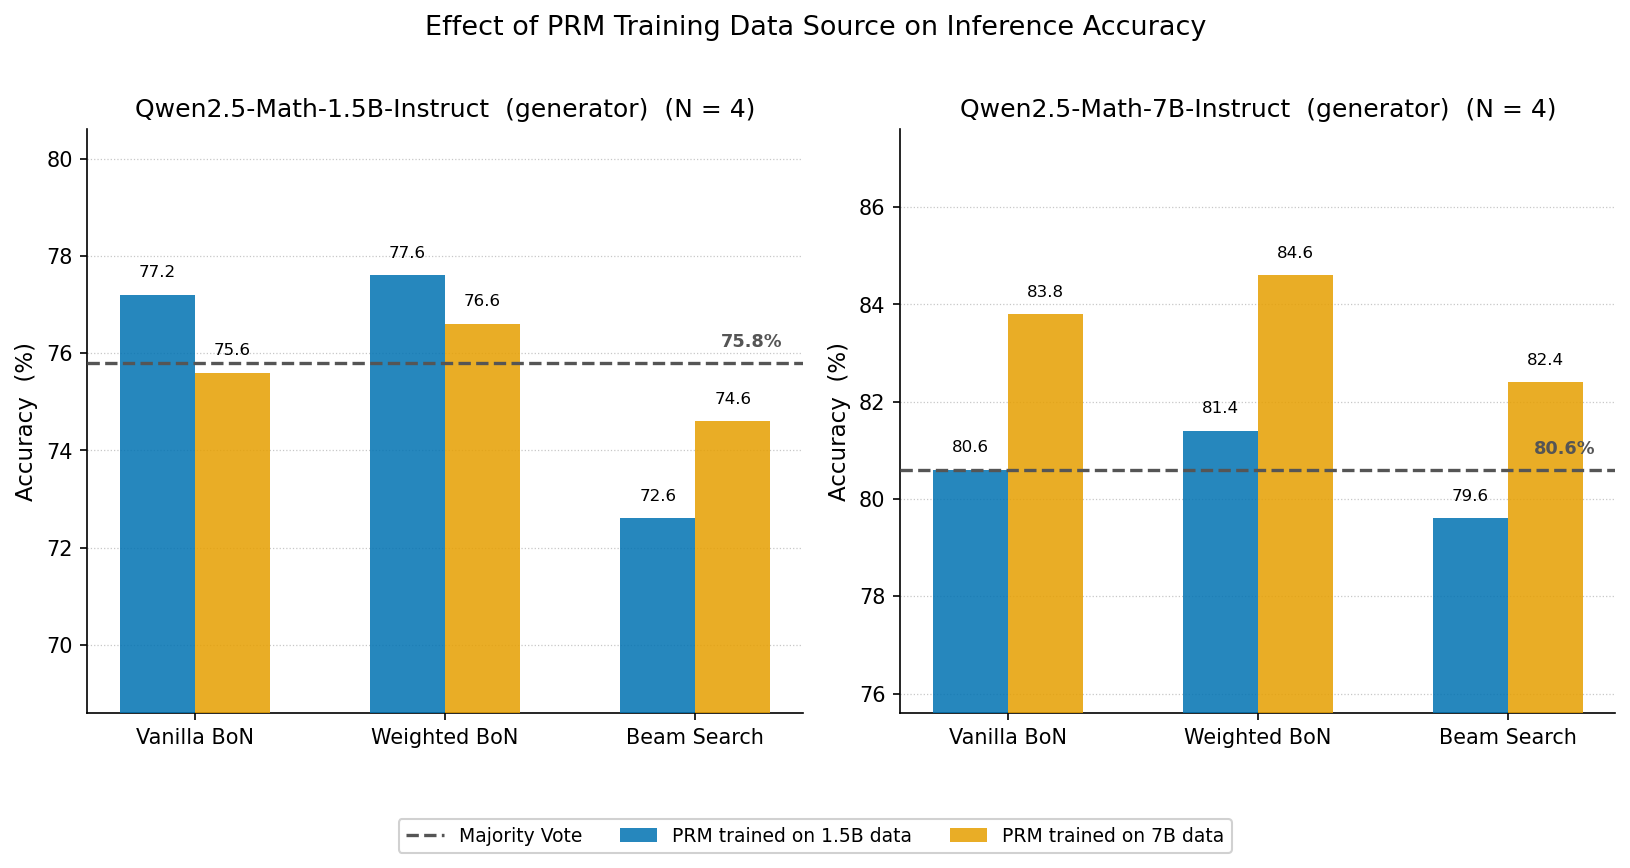

Saved → Figs/prm_data_source_comparison.png


In [22]:
def get_at_N(results, N_target):
    """Return the result dict for a specific rollout budget."""
    for r in results:
        if r['rollouts'] == N_target:
            return r
    raise KeyError(f'N={N_target} not found')


N_COMPARE = 4
r15 = get_at_N(results_1p5B, N_COMPARE)
r7  = get_at_N(results_7B,   N_COMPARE)

# Method groups to compare (label, key_15, key_7)
COMPARE_METHODS = [
    ('Vanilla BoN',    'vanilla_best_of_N_15',  'vanilla_best_of_N_7'),
    ('Weighted BoN',   'weighted_best_of_N_15', 'weighted_best_of_N_7'),
    ('Beam Search',    'beam_search_15',        'beam_search_7'),
]

x       = np.arange(len(COMPARE_METHODS))
bar_w   = 0.30
offsets = [-bar_w / 2, bar_w / 2]      # 1.5B-PRM vs 7B-PRM
prm_labels  = ['PRM trained on 1.5B data', 'PRM trained on 7B data']
prm_colors  = ['#0072B2', '#E69F00']    # blue, amber


def plot_prm_comparison(ax, result, gen_label, beam_M=4):
    majority_acc = result['accuracies']['majority_vote'] * 100

    for col_idx, (prm_key_suffix, label, color) in enumerate(
            zip(['_15', '_7'], prm_labels, prm_colors)):
        accs = []
        for _, key15, key7 in COMPARE_METHODS:
            key  = key15 if prm_key_suffix == '_15' else key7
            acc  = result['accuracies'][key] * 100
            # If beam search wasn't run (N < M) → show NaN
            if 'beam_search' in key and result['rollouts'] < beam_M:
                acc = float('nan')
            accs.append(acc)

        bars = ax.bar(x + offsets[col_idx], accs, width=bar_w,
                      color=color, alpha=0.85, label=label, zorder=3)

        # Annotate bar tops
        for bar, v in zip(bars, accs):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.3,
                        f'{v:.1f}', ha='center', va='bottom', fontsize=8)

    # Majority vote baseline — label without the accuracy value
    ax.axhline(majority_acc, color=COLORS['majority'], linewidth=1.6,
               linestyle='--', zorder=4, label='Majority Vote')

    # Annotate the accuracy directly above the dashed line (right-aligned)
    x_right = x[-1] + bar_w + 0.05
    ax.text(x_right, majority_acc + 0.25,
            f'{majority_acc:.1f}%',
            ha='right', va='bottom', fontsize=8.5,
            color=COLORS['majority'], fontweight='bold')

    ax.set_title(f'{gen_label}  (N = {N_COMPARE})')
    ax.set_ylabel('Accuracy  (%)')
    ax.set_xticks(x)
    ax.set_xticklabels([m[0] for m in COMPARE_METHODS])
    ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7, zorder=0)
    ax.set_axisbelow(True)

    # Y-axis range: auto-adjust with a small margin
    all_vals = [result['accuracies'][k15] * 100 for _, k15, _ in COMPARE_METHODS]
    all_vals += [result['accuracies'][k7] * 100 for _, _, k7 in COMPARE_METHODS]
    all_vals += [majority_acc]
    all_vals = [v for v in all_vals if not np.isnan(v)]
    lo, hi = min(all_vals), max(all_vals)
    ax.set_ylim(max(0, lo - 4), hi + 3)


fig2, axes2 = plt.subplots(1, 2, figsize=(11, 5), sharey=False)

plot_prm_comparison(axes2[0], r15, 'Qwen2.5-Math-1.5B-Instruct  (generator)')
plot_prm_comparison(axes2[1], r7,  'Qwen2.5-Math-7B-Instruct  (generator)')

# Combined legend below both subplots
handles2, labels2 = axes2[0].get_legend_handles_labels()
fig2.legend(handles2, labels2,
            loc='lower center', ncol=3,
            bbox_to_anchor=(0.5, -0.12),
            frameon=True, framealpha=0.9)

fig2.suptitle('Effect of PRM Training Data Source on Inference Accuracy', fontsize=13, y=1.01)
fig2.tight_layout()
fig2.savefig(FIGS_DIR / 'prm_data_source_comparison.png', bbox_inches='tight')
plt.show()
print('Saved → Figs/prm_data_source_comparison.png')

## Summary Table  (N = 4)

In [23]:
import pandas as pd

TABLE_METHODS = [
    ('majority_vote',          'Majority Vote',              '—'),
    ('vanilla_best_of_N_15',   'Vanilla Best-of-N',          'PRM (1.5B data)'),
    ('weighted_best_of_N_15',  'Weighted Best-of-N',         'PRM (1.5B data)'),
    ('beam_search_15',         'Beam Search',                'PRM (1.5B data)'),
    ('vanilla_best_of_N_7',    'Vanilla Best-of-N',          'PRM (7B data)'),
    ('weighted_best_of_N_7',   'Weighted Best-of-N',         'PRM (7B data)'),
    ('beam_search_7',          'Beam Search',                'PRM (7B data)'),
]

r15_n4 = get_at_N(results_1p5B, 4)
r7_n4  = get_at_N(results_7B,   4)

rows = []
for key, method, prm in TABLE_METHODS:
    acc_1p5B = r15_n4['accuracies'][key] * 100
    acc_7B   = r7_n4['accuracies'][key]  * 100
    rows.append({'Method': method, 'PRM': prm,
                 '1.5B Generator (%)': f'{acc_1p5B:.1f}',
                 '7B Generator (%)':   f'{acc_7B:.1f}'})

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df

            Method             PRM 1.5B Generator (%) 7B Generator (%)
     Majority Vote               —               75.8             80.6
 Vanilla Best-of-N PRM (1.5B data)               77.2             80.6
Weighted Best-of-N PRM (1.5B data)               77.6             81.4
       Beam Search PRM (1.5B data)               72.6             79.6
 Vanilla Best-of-N   PRM (7B data)               75.6             83.8
Weighted Best-of-N   PRM (7B data)               76.6             84.6
       Beam Search   PRM (7B data)               74.6             82.4


,Method,PRM,1.5B Generator (%),7B Generator (%)
0,Majority Vote,—,75.8,80.6
1,Vanilla Best-of-N,PRM (1.5B data),77.2,80.6
2,Weighted Best-of-N,PRM (1.5B data),77.6,81.4
3,Beam Search,PRM (1.5B data),72.6,79.6
4,Vanilla Best-of-N,PRM (7B data),75.6,83.8
5,Weighted Best-of-N,PRM (7B data),76.6,84.6
6,Beam Search,PRM (7B data),74.6,82.4
